In [1]:
import pyvista as pv
import subprocess

In [4]:
result = subprocess.run(['build/pde/e_emf'], cwd='../../../', capture_output=True, text=True, check=True)
print(result.stdout)

Areas: 18
Vertices: 1539
Elements: 1456
Segments: 164
Az(2.52e-02, 1.60e-03) = 9.8546892e-03
Az(3.35e-02, 2.70e-03) = 1.7139686e-03
Az(3.50e-02, 9.00e-04) = 1.1544334e-03
Az(3.65e-02, 2.70e-03) = -1.3034607e-03
Az(4.29e-02, 3.50e-03) = -8.6242210e-03

Error: 0.0000001
Iterations: 703



2026-03-11 16:11:58.825 (  11.744s) [    7FCA83BA2740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


MultiBlock (0x7fca7e2207c0)
  N Blocks:   1
  X Bounds:   -1.000e-02, 8.000e-02
  Y Bounds:   0.000e+00, 6.000e-02
  Z Bounds:   0.000e+00, 0.000e+00


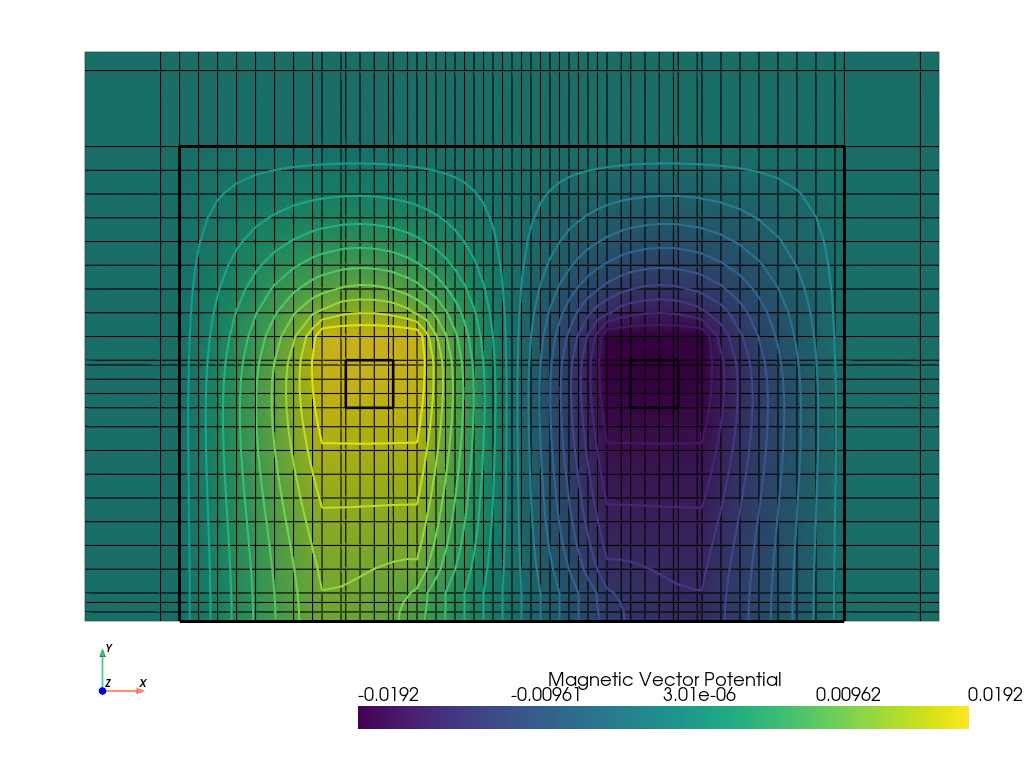

In [3]:
reader = pv.CGNSReader('out/emf.cgns')
msh = reader.read()
plotter = pv.Plotter()

print(msh)

isolines = msh.combine().contour(isosurfaces=20, scalars='Magnetic Vector Potential')

plotter.add_mesh(msh, show_edges=True, scalars='Magnetic Vector Potential')
plotter.add_mesh(isolines, line_width=2, show_scalar_bar=True)

plotter.add_mesh(pv.Rectangle([[0.07, 0, 0], [0.07, 0.05, 0], [0, 0.05, 0]]), 
                 line_width=3, 
                 color='black',
                 style='wireframe')

plotter.add_mesh(pv.Rectangle([[0.0225, 0.0225, 0], [0.0225, 0.0275, 0], [0.0175, 0.0275, 0]]), 
                 line_width=3, 
                 color='black',
                 style='wireframe')

plotter.add_mesh(pv.Rectangle([[0.0525, 0.0225, 0], [0.0525, 0.0275, 0], [0.0475, 0.0275, 0]]), 
                 line_width=3, 
                 color='black',
                 style='wireframe')

plotter.camera_position = 'xy'
plotter.reset_camera(bounds=[0.005, 0.065, 0.0, 0.05, 0, 0])
plotter.zoom_camera(1)
plotter.show_axes()
plotter.show(jupyter_backend='static')